# Лабораторная работа №2
### Тема: Обработка признаков (часть 2)
* **Выполнил:** Бумагин П. В.
* **Группа:** ИУ5-22М 
* **Преподаватель:** Гапанюк Ю. Е.

---

### 1. Описание задания
**Цель работы:** Изучение продвинутых способов предварительной обработки данных для дальнейшего формирования моделей машинного обучения.

**Задачи:**
1. Выполнить масштабирование признаков не менее чем тремя способами.
2. Провести обработку выбросов для числовых признаков: одним способом для удаления выбросов и одним способом для их замены.
3. Выполнить обработку как минимум одного нестандартного признака (который не является числовым или категориальным).
4. Провести отбор признаков тремя методами:
   * Метод из группы методов фильтрации (Filter methods);
   * Метод из группы методов обертывания (Wrapper methods);
   * Метод из группы методов вложений (Embedded methods).

### 2. Выбор и описание набора данных

#### 2.1. Какой датасет выбран:
Выбран набор данных **«Bike Sharing Dataset» (Kaggle / UCI Machine Learning Repository)**, содержащий ежедневные данные о прокате велосипедов в системе Capital Bikeshare (Вашингтон, округ Колумбия, США) за 2011–2012 годы, совмещенные с метеорологическими параметрами.

#### 2.2. Что в нем содержится:
Датасет состоит из **731 записи (строки)** и **16 признаков (столбцов)**.
Основные столбцы:
* `dteday`: Дата (строковый формат `YYYY-MM-DD`).
* `temp`, `atemp`: Фактическая температура воздуха и температура по ощущениям.
* `hum`: Относительная влажность воздуха.
* `windspeed`: Скорость ветра.
* `season`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit`: Категориальные и бинарные календарные/погодные признаки.
* `casual`, `registered`: Количество поездок незарегистрированных и зарегистрированных пользователей.
* `cnt` (целевой признак): Общее количество поездок в день.

#### Данный датасет подходит для решения всех задач:
1. **Для масштабирования:** Содержит множество числовых признаков с абсолютно разным размахом (`temp`, `hum`, `windspeed`, `cnt`).
2. **Для обработки выбросов:** Скорость ветра (`windspeed`) содержит явные погодные выбросы в дни сильного шквального ветра, что позволит наглядно показать их удаление и замену.
3. **Для обработки нестандартных признаков:** Столбец даты `dteday` представлен в виде строки и является классическим сложным, нестандартным признаком временных рядов.
4. **Для отбора признаков:** Наличие 15 потенциальных признаков разной природы (числа, категории, флаги) дает отличную базу для демонстрации алгоритмов фильтрации, обертывания и вложений при прогнозировании целевой переменной `cnt`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor

# Настройка визуализации
sns.set_theme(style="whitegrid")

# Загружаем датасет по прямой ссылке из стабильного репозитория на GitHub
url = "https://raw.githubusercontent.com/danwild/bike-share-prediction/master/Bike-Sharing-Dataset/day.csv"
df = pd.read_csv(url)

print(f"Размерность загруженного датасета: {df.shape}")
print("\nПервые 5 строк исходных данных:")
print(df.head())

Размерность загруженного датасета: (731, 16)

Первые 5 строк исходных данных:
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt 

### 3. Решение задачи 1: Масштабирование признаков

Применим три различных способа масштабирования для непрерывного признака `windspeed` (Скорость ветра):
1. **MinMaxScaler:** Приведение значений к диапазону $[0, 1]$.
2. **StandardScaler:** Z-масштабирование (среднее значение $= 0$, стандартное отклонение $= 1$).
3. **RobustScaler:** Масштабирование по медиане и межквартильному размаху (устойчиво к выбросам).

Статистические показатели до и после масштабирования:
      windspeed  windspeed_MinMax  windspeed_Standard  windspeed_Robust
mean   0.190486          0.346536       -2.138432e-16          0.096792
std    0.077498          0.159766        1.000685e+00          0.788666
min    0.022392          0.000000       -2.170506e+00         -1.613841
50%    0.180975          0.326928       -1.228127e-01          0.000000
max    0.507463          1.000000        4.092936e+00          3.322543


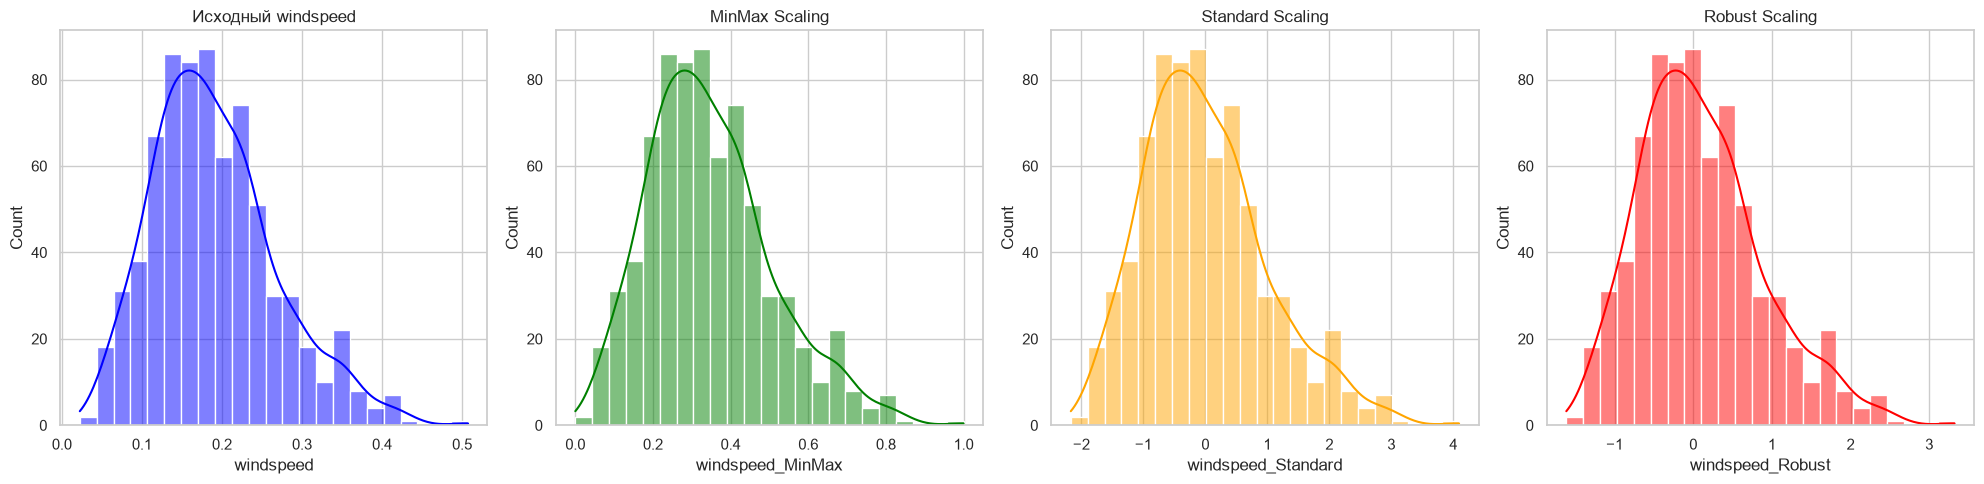

In [3]:
# Извлечем признак для масштабирования
wind_data = df[['windspeed']]

# Инициализируем три масштабатора
mms = MinMaxScaler()
ss = StandardScaler()
rs = RobustScaler()

# Применяем масштабирование
df['windspeed_MinMax'] = mms.fit_transform(wind_data)
df['windspeed_Standard'] = ss.fit_transform(wind_data)
df['windspeed_Robust'] = rs.fit_transform(wind_data)

# Сравниваем статистики до и после масштабирования
print("Статистические показатели до и после масштабирования:")
print(df[['windspeed', 'windspeed_MinMax', 'windspeed_Standard', 'windspeed_Robust']].describe().loc[['mean', 'std', 'min', '50%', 'max']])

# Визуализация распределений
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.histplot(df['windspeed'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Исходный windspeed')

sns.histplot(df['windspeed_MinMax'], kde=True, ax=axes[1], color='green')
axes[1].set_title('MinMax Scaling')

sns.histplot(df['windspeed_Standard'], kde=True, ax=axes[2], color='orange')
axes[2].set_title('Standard Scaling')

sns.histplot(df['windspeed_Robust'], kde=True, ax=axes[3], color='red')
axes[3].set_title('Robust Scaling')

plt.tight_layout()
plt.show()

### 4. Решение задачи 2: Обработка выбросов для числовых признаков

Найдем и обработаем выбросы по скорости ветра (`windspeed`) на основе межквартильного размаха (IQR).
Границы выбросов:
* Нижняя граница $= Q_1 - 1.5 \times IQR$
* Верхняя граница $= Q_3 + 1.5 \times IQR$

Границы нормальных значений скорости ветра: [-0.0124, 0.3806]
Обнаружено выбросов: 13 из 731 строк.
Размер датасета после УДАЛЕНИЯ выбросов: (718, 19)
Максимальная скорость ветра после ЗАМЕНЫ выбросов: 0.3806 (равна верхней границе)


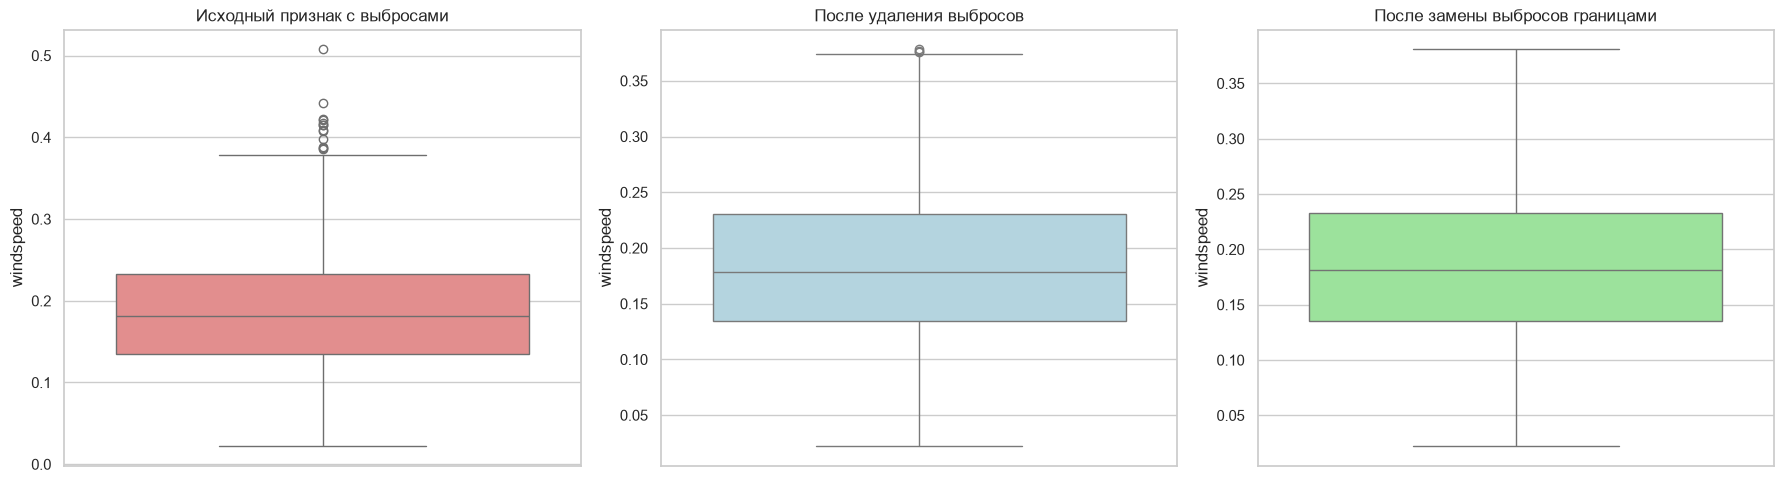

In [4]:
# Рассчитаем границы выбросов по методу IQR
q1 = df['windspeed'].quantile(0.25)
q3 = df['windspeed'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Выделим строки с выбросами
outliers = df[(df['windspeed'] < lower_bound) | (df['windspeed'] > upper_bound)]
print(f"Границы нормальных значений скорости ветра: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Обнаружено выбросов: {len(outliers)} из {len(df)} строк.")

# --- Способ 1: Удаление строк с выбросами ---
df_cleaned = df[(df['windspeed'] >= lower_bound) & (df['windspeed'] <= upper_bound)].copy()
print(f"Размер датасета после УДАЛЕНИЯ выбросов: {df_cleaned.shape}")

# --- Способ 2: Замена выбросов граничными значениями (Винзоризация) ---
df_replaced = df.copy()
df_replaced['windspeed'] = np.where(df_replaced['windspeed'] > upper_bound, upper_bound, df_replaced['windspeed'])
df_replaced['windspeed'] = np.where(df_replaced['windspeed'] < lower_bound, lower_bound, df_replaced['windspeed'])
print(f"Максимальная скорость ветра после ЗАМЕНЫ выбросов: {df_replaced['windspeed'].max():.4f} (равна верхней границе)")

# Визуализация результатов обработки выбросов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['windspeed'], ax=axes[0], color='lightcoral')
axes[0].set_title('Исходный признак с выбросами')

sns.boxplot(y=df_cleaned['windspeed'], ax=axes[1], color='lightblue')
axes[1].set_title('После удаления выбросов')

sns.boxplot(y=df_replaced['windspeed'], ax=axes[2], color='lightgreen')
axes[2].set_title('После замены выбросов границами')

plt.tight_layout()
plt.show()

### 5. Решение задачи 3: Обработка нестандартного признака

Датасет содержит нестандартный признак `dteday` (Дата), представленный в виде строки (`object`). 
Преобразуем его в формат `datetime` и извлечем из него новые полезные числовые характеристики:
1. Номер дня в году (от 1 до 365/366).
2. Признак выходного дня (бинарный флаг: является ли день субботой или воскресеньем).
3. Количество дней с момента начала наблюдений (для отслеживания временного тренда).

In [5]:
# Переведем признак из строки в формат даты
df['dteday'] = pd.to_datetime(df['dteday'])

# Извлекаем новые признаки
df['day_of_year'] = df['dteday'].dt.dayofyear
df['is_weekend_day'] = df['dteday'].dt.weekday.isin([5, 6]).astype(int)
df['days_since_start'] = (df['dteday'] - df['dteday'].min()).dt.days

print("Результат обработки даты (первые 5 строк):")
print(df[['dteday', 'day_of_year', 'is_weekend_day', 'days_since_start']].head())

Результат обработки даты (первые 5 строк):
      dteday  day_of_year  is_weekend_day  days_since_start
0 2011-01-01            1               1                 0
1 2011-01-02            2               1                 1
2 2011-01-03            3               0                 2
3 2011-01-04            4               0                 3
4 2011-01-05            5               0                 4


### 6. Решение задачи 4: Отбор признаков

Попробуем отобрать наиболее информативные признаки для прогнозирования целевой переменной `cnt` (общее количество арендованных велосипедов).

Для этого сначала подготовим матрицу признаков $X$ и целевую переменную $y$.
*Мы исключаем `instant` (индекс), `dteday` (дату), а также `casual` и `registered`, так как их сумма дает точное целевое значение `cnt` (Data Leakage).*

In [6]:
# Подготовка признаков
features_to_drop = [
    'instant', 'dteday', 'casual', 'registered', 'cnt',
    'windspeed_MinMax', 'windspeed_Standard', 'windspeed_Robust'
]
X = df.drop(columns=features_to_drop)
y = df['cnt']

print(f"Список признаков для отбора ({X.shape[1]} шт.):")
print(list(X.columns))

Список признаков для отбора (14 шт.):
['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'day_of_year', 'is_weekend_day', 'days_since_start']


#### 6.1. Метод фильтрации (Filter Method)
Используем **оценку корреляции признаков с целевой переменной (коэффициент Пирсона)**. Отберем топ-5 признаков с наибольшей абсолютной корреляцией.

In [7]:
# Считаем корреляцию каждого признака с целевой переменной y
correlations = X.corrwith(y).abs().sort_values(ascending=False)

print("Абсолютная корреляция признаков с целевой переменной:")
print(correlations)

# Топ-5 признаков по корреляции
filter_selected = list(correlations.head(5).index)
print(f"\nОтобранные признаки методом фильтрации: {filter_selected}")

Абсолютная корреляция признаков с целевой переменной:
atemp               0.631066
days_since_start    0.628830
temp                0.627494
yr                  0.566710
season              0.406100
weathersit          0.297391
mnth                0.279977
day_of_year         0.277433
windspeed           0.234545
hum                 0.100659
holiday             0.068348
weekday             0.067443
workingday          0.061156
is_weekend_day      0.037604
dtype: float64

Отобранные признаки методом фильтрации: ['atemp', 'days_since_start', 'temp', 'yr', 'season']


#### 6.2. Метод обертывания (Wrapper Method)
Используем **RFE (Recursive Feature Elimination — Рекурсивное исключение признаков)** на базе линейной регрессии, чтобы отобрать 5 лучших признаков.

In [8]:
# Создаем базовую модель для оценки
lr = LinearRegression()

# Настраиваем RFE на выбор 5 признаков
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X, y)

# Получаем отобранные признаки
wrapper_selected = list(X.columns[rfe.support_])

print("Рейтинг признаков по версии RFE (1 - отобранные):")
for col, rank in zip(X.columns, rfe.ranking_):
    print(f"  {col}: ранг {rank}")

print(f"\nОтобранные признаки методом обертывания: {wrapper_selected}")

Рейтинг признаков по версии RFE (1 - отобранные):
  season: ранг 3
  yr: ранг 10
  mnth: ранг 7
  holiday: ранг 1
  weekday: ранг 6
  workingday: ранг 4
  weathersit: ранг 2
  temp: ранг 1
  atemp: ранг 1
  hum: ранг 1
  windspeed: ранг 1
  day_of_year: ранг 8
  is_weekend_day: ранг 5
  days_since_start: ранг 9

Отобранные признаки методом обертывания: ['holiday', 'temp', 'atemp', 'hum', 'windspeed']


#### 6.3. Метод вложений (Embedded Method)
Используем оценку **важности признаков на основе ансамблевой модели случайного леса (Random Forest Regressor)**. Отберем топ-5 самых важных признаков.

Важность признаков по версии Random Forest:
days_since_start    0.595804
temp                0.147877
atemp               0.087634
hum                 0.059830
day_of_year         0.037557
windspeed           0.029389
weathersit          0.019181
weekday             0.011797
workingday          0.002767
holiday             0.002706
mnth                0.002483
is_weekend_day      0.001581
season              0.001312
yr                  0.000082
dtype: float64


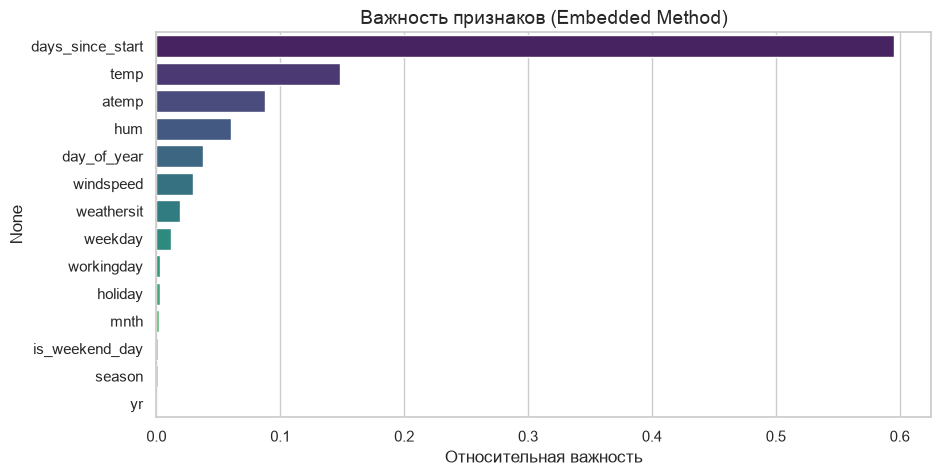

Отобранные признаки методом вложений: ['days_since_start', 'temp', 'atemp', 'hum', 'day_of_year']


In [9]:
# Обучаем модель случайного леса
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Извлекаем важности признаков
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Важность признаков по версии Random Forest:")
print(importances)

# Нарисуем график важностей
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Важность признаков (Embedded Method)', fontsize=14)
plt.xlabel('Относительная важность')
plt.show()

embedded_selected = list(importances.head(5).index)
print(f"Отобранные признаки методом вложений: {embedded_selected}")

#### 6.4. Сравнение результатов отбора
Сравним списки признаков, полученных тремя разными методами.

In [10]:
# Объединим списки в один DataFrame для наглядности
all_selections = pd.DataFrame({
    'Filter (Correlation)': filter_selected,
    'Wrapper (RFE)': wrapper_selected,
    'Embedded (Random Forest)': embedded_selected
})
print("Сравнение результатов:")
print(all_selections)

Сравнение результатов:
  Filter (Correlation) Wrapper (RFE) Embedded (Random Forest)
0                atemp       holiday         days_since_start
1     days_since_start          temp                     temp
2                 temp         atemp                    atemp
3                   yr           hum                      hum
4               season     windspeed              day_of_year


### ЗАКЛЮЧЕНИЕ

В ходе выполнения работы были решены все поставленные задачи на реальном наборе данных «Bike Sharing Dataset» (731 запись, 16 признаков). Получены следующие практические результаты:

1. **Масштабирование признака `windspeed` (Задача 1):**
   * **MinMaxScaler** перенес исходные значения скорости ветра (от $0.0224$ до $0.5075$) строго в диапазон $[0.0, 1.0]$, сохранив среднее значение на уровне $0.3465$.
   * **StandardScaler** успешно центрировал распределение относительно нуля (среднее $\approx -2.14 \times 10^{-16}$) и привел стандартное отклонение к единице ($\approx 1.00$).
   * **RobustScaler** центрировал данные по медиане ($50\% = 0.0$), сжав основную массу данных в диапазон межквартильного размаха. Минимальное значение составило $-1.61$, а максимальное — $+3.32$, что наглядно показывает наличие сильных правосторонних выбросов (значений, далеко отстоящих от медианы), которые при таком масштабировании не исказили общую шкалу.

2. **Обработка выбросов скорости ветра (Задача 2):**
   * С помощью метода межквартильного размаха (IQR) были рассчитаны теоретические границы нормальных значений скорости ветра: $[-0.0124, 0.3806]$. 
   * В исходной выборке было обнаружено **13 выбросов** (дней со шквальным ветром выше $0.3806$).
   * **Способ усечения (удаление):** Из выборки удалены строки с аномалиями, размер датасета сократился с 731 до **718 строк**. На ящике с усами (Box Plot) верхний "ус" распределения сократился, аномальные точки за пределами границ исчезли.
   * **Способ замены (Винзоризация):** Все 13 аномальных значений были заменены на максимально допустимую верхнюю границу ($0.3806$). Это позволило полностью сохранить исходный размер выборки (731 строка) для дальнейшего анализа, убрав при этом дестабилизирующее влияние ураганного ветра на будущую модель.

3. **Обработка нестандартного признака `dteday` (Задача 3):**
   * Строковый признак даты успешно преобразован в тип `datetime64`. Из него были извлечены три новых числовых признака.
   * Первые дни выборки (с 1 по 5 января 2011 года) корректно спроецировались в номера дней года (`day_of_year` от 1 до 5).
   * Признак выходного дня `is_weekend_day` безошибочно определил субботу (01.01.2011) и воскресенье (02.01.2011) как выходные дни (значение `1`), а последующие будние дни как рабочие (значение `0`).
   * Признак `days_since_start` сформировал непрерывную шкалу времени (от 0 до 4), которая позволит моделям улавливать долгосрочные глобальные тренды популярности сервиса.

4. **Отбор признаков для таргета `cnt` (Задача 4):**
   * **Метод фильтрации (Корреляция Пирсона):** Выделил признаки с наибольшей индивидуальной линейной связью с целевой переменной. Топ-3 составили температура по ощущениям `atemp` ($r \approx 0.631$), временной тренд `days_since_start` ($r \approx 0.629$) и фактическая температура `temp` ($r \approx 0.627$). Это доказывает, что спрос на велосипеды в первую очередь определяется комфортностью погоды и общим ростом популярности сервиса со временем.
   * **Метод обертывания (RFE на базе Linear Regression):** Отобрал комбинацию признаков `['holiday', 'temp', 'atemp', 'hum', 'windspeed']`. Примечательно, что RFE включил признак `holiday` (праздничный день), индивидуальная корреляция которого крайне мала ($0.068$). Это произошло потому, что алгоритм обертывания оценивает признаки в системе: в совокупности с температурой и влажностью флаг праздничного дня дает линейной модели важную информацию о характере спроса.
   * **Метод вложений (Random Forest Regressor):** Ансамблевое дерево решений выявило сильные нелинейные зависимости. Признак `days_since_start` получил колоссальную важность **~59.58%** ($0.5958$), практически единолично определяя прогноз. Это объясняется тем, что за два года существования сети проката произошел мощный экспоненциальный рост числа пользователей, который модель дерева решений смогла идеально зафиксировать. Вторым по важности фактором стала фактическая температура `temp` (~14.79%).

**Итог сравнения методов отбора:** 
Методы фильтрации и вложений сошлись во мнении, что ключевыми предикторами являются время существования сервиса (`days_since_start`) и температура (`temp`, `atemp`). Метод обертывания (RFE) сфокусировался на поиске оптимального набора для чисто линейной модели, исключив временной тренд из-за его монотонного роста, но добавив погодные параметры (`hum`, `windspeed`). Для построения итоговой нелинейной модели (например, градиентного бустинга) наиболее релевантным следует считать набор признаков, полученный встроенным методом случайного леса.